In [1]:
# @launchit.collected

# Begin

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict # @launchit.collect
import json
import datetime
import pprint
import re
import pickle
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
from io import BytesIO
import sqlite3
import glob
import zipfile

from tqdm import tqdm

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import StackDataset, DataLoader

import numpy as np
import pandas as pd
import einops
import matplotlib.pyplot as plt

from PIL import Image

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
import launchit # @launchit.disable
from logging_utils import *
from image_utils import *
from artifact_registry import *
import db_utils
from hp_utils import *
from autoincrement import Autoincrement

# Init

In [3]:
ArrayUtils.init()
LOG = Logging.get()
RNG = np.random.default_rng()

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    model_group_uri=None,
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    private_data_path=None,
    run_path=None,
    self_fname=None,
    self_name=None,
    subproject_name=None,
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'model_group_uri': 'com.develorium.neurovision.16_hybrid',
 'subproject_path': '/home/misha/dev/mine/neurovision/16_hybrid',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/16_hybrid',
 'run_path': '/home/misha/dev/mine/neurovision/run/16_hybrid',
 'self_fname': '/home/misha/dev/mine/neurovision/16_hybrid/16a_dataset_01.ipynb',
 'self_name': '16a_dataset_01',
 'subproject_name': '16_hybrid',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [4]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    db_fname: str = None
    target_image_size: int = None
    images_preprocessing: str = None
    batch_size: int = None
    batches_count: int = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 42
HP.target_image_size = 128

# Launch

## Bootstrap

In [5]:
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

ARTIFACT_REGISTRY = ArtifactRegistry(maven_group_id=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')

Random seed=42


# Images

## Images

In [6]:
@dataclass
class Images:
    mnist: object = None
    chars74k: object = None

IMAGES = Images()

## Load

### MNIST

In [7]:
mnist_path = os.path.join(CONFIG.data_path, 'mnist')
IMAGES.mnist = namedtuple('MNIST', 'images labels test_images test_labels')(
    *get_mnist_images(mnist_path, 'TRAIN'),
    *get_mnist_images(mnist_path, 'TEST'),
)
len(IMAGES.mnist.images), len(IMAGES.mnist.test_images)

(60000, 10000)

### CHARS74K

In [8]:
chars74k_path = os.path.join(CONFIG.data_path, 'chars74k')
os.makedirs(chars74k_path, exist_ok=True)
artifact_registry = ArtifactRegistry('com.kaggle')
zip_file = artifact_registry.get_asset_content('chars74k', 1, 'zip')

with BytesIO(zip_file) as b:
    with zipfile.ZipFile(b, 'r') as z:
        z.extractall(chars74k_path)

In [9]:
images = []

for label in range(10):
    label_dirname = os.path.join(chars74k_path, f'Sample{label+1:03}')
    fnames = list(glob.glob(os.path.join(label_dirname, "*")))
    labels = [label] * len(fnames)
    images.extend(zip(fnames, labels))

IMAGES.chars74k = namedtuple('CHARS74K', 'train test')(*train_test_split(images))

# Create dataset

## Configure

In [10]:
# @launchit.disable
# @launchit.collect
HP.db_fname = 'dataset.db'
HP.images_preprocessing = 'UNINORM'
HP.batch_size = 1000
HP.batches_count = 1
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 42,
 'db_fname': 'dataset.db',
 'target_image_size': 128,
 'images_preprocessing': 'UNINORM',
 'batch_size': 1000,
 'batches_count': 1}


## get_full_db_fname

In [11]:
def get_full_db_fname():
    return os.path.join(CONFIG.private_data_path, HP.db_fname)

## get_db_con

In [72]:
def get_db_con(is_read_only=False, is_auto_commit=True):
    if not is_read_only:
        return sqlite3.connect(get_full_db_fname(), autocommit=is_auto_commit)

    return sqlite3.connect(f'file:{get_full_db_fname()}?mode=ro', uri=True)

## Populate

### meta

In [12]:
with get_db_con() as db_con:
    df = pd.DataFrame(
        dict(
            image_size=[HP.target_image_size],
        ),
    )
    df.to_sql('meta', con=db_con, if_exists='replace', index=False)
    LOG(f'{get_full_db_fname()}: table "meta" populated, {len(df)} rows')

/home/misha/dev/mine/neurovision/data/16_hybrid/dataset.db: table "meta" populated, 1 rows


### images & test_images

In [28]:
scaler = None

with get_db_con(is_auto_commit=False) as db_con:
    for table_name, is_test, (mnist_images, mnist_labels, chars74k_items) in zip(
        ('images', 'test_images'), 
        (False, True),
        (
            (IMAGES.mnist.images, IMAGES.mnist.labels, IMAGES.chars74k.train), 
            (IMAGES.mnist.test_images, IMAGES.mnist.test_labels, IMAGES.chars74k.test)
        ), 
    ):
        db_utils.drop_table_safe(db_con, table_name)

        assert len(mnist_images) == len(mnist_labels)
        data_loader = DataLoader(StackDataset(mnist_images, mnist_labels), shuffle=False, batch_size=HP.batch_size)
        batches_count = LangUtils.coalesce(HP.batches_count, len(data_loader))

        for _, (images, labels) in tqdm(zip(range(batches_count), data_loader), ncols=100, total=batches_count):
            columns = defaultdict(list)
            columns['label'].extend(labels.tolist())
            columns['source'].extend(['mnist'] * len(columns['label']))
            images_hat = []
    
            for image in images:
                pil_image = Image.fromarray(image.numpy())
                pil_image = pil_image.resize((HP.target_image_size, HP.target_image_size))
                images_hat.append(np.array(pil_image))

            images_hat = np.array(images_hat)
            images_hat, scaler = preprocess_images(images_hat, HP.images_preprocessing, scaler)

            for image in images_hat:
                with BytesIO() as b:
                    np.save(b, image)
                    columns['data'].append(b.getvalue())

            df = pd.DataFrame(columns)
            df.to_sql(table_name, con=db_con, if_exists='append', index=False)
            db_con.commit()

        data_loader = DataLoader(chars74k_items, shuffle=False, batch_size=HP.batch_size)
        batches_count = LangUtils.coalesce(HP.batches_count, len(data_loader))

        for _, (items) in tqdm(zip(range(batches_count), data_loader), ncols=100, total=batches_count):
            columns = defaultdict(list)
            images_hat = []
            
            for fname, label in zip(*items):
                pil_image = Image.open(fname)
                pil_image = pil_image.resize((HP.target_image_size, HP.target_image_size))
                image = np.array(pil_image)
                # invert black to white as it's in MNIST
                image = 255 - image
                images_hat.append(image)
                columns['label'].append(label.item())

            images_hat = np.array(images_hat)
            images_hat, scaler = preprocess_images(images_hat, HP.images_preprocessing, scaler)

            for image in images_hat:
                with BytesIO() as b:
                    np.save(b, image)
                    columns['data'].append(b.getvalue())
            
            columns['source'].extend(['chars74k'] * len(columns['label']))

            df = pd.DataFrame(columns)
            df.to_sql(table_name, con=db_con, if_exists='append', index=False)
            db_con.commit()
            
        rows_count = db_utils.get_rows_count(db_con, table_name)
        LOG(f'{get_full_db_fname()}: table "{table_name}" populated, {rows_count} rows')

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.44it/s]

/home/misha/dev/mine/neurovision/data/16_hybrid/dataset.db: table "images" populated, 2000 rows



100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.41it/s]

/home/misha/dev/mine/neurovision/data/16_hybrid/dataset.db: table "test_images" populated, 2000 rows


# Verify dataset

## Verify target size

In [76]:
with get_db_con(is_read_only=True) as db_con:
    for table_name in ('images', 'test_images'):
        cur = db_con.cursor()
        
        for image_ind, data in tqdm(cur.execute(f'SELECT ROWID, data FROM {table_name}')):
            image = np.load(BytesIO(data))
            assert image.shape == (HP.target_image_size, HP.target_image_size), (table_name, image_ind, image.shape)

2000it [00:00, 21474.95it/s]
2000it [00:00, 24931.74it/s]


## visualize_images

In [92]:
def visualize_images(source, is_test):
    fig, axes = plt.subplots(2, 5)
    fig.set_figwidth(16)
    fig.set_figheight(2.2 * len(axes))
    fig.suptitle(f'{source=}, {is_test=}')
    
    with sqlite3.connect(get_full_db_fname(), autocommit=False) as db_con:
        table_name = ('images', 'test_images')[is_test]
        where_q, where_v = LangUtils.when(
            source is not None, 
            ('source=?', (source,)), 
            ('1', ()),
        )
        image_inds = list(map(lambda i: i[0], db_con.execute(f'SELECT ROWID FROM {table_name} WHERE {where_q}', where_v).fetchall()))
        image_inds = RNG.choice(image_inds, 10, replace=False)
    
        for image_ind, ax in zip(image_inds, axes.ravel()):
            data, source, label = db_con.execute(f'SELECT data, source, label FROM {table_name} WHERE ROWID=?', (image_ind.item(),)).fetchone()
            ax.set_title(f'{source} #{image_ind}, label={label}', fontdict=dict(fontsize=10))
            im = ax.imshow(np.load(BytesIO(data)));
            ax.set_axis_off();
            fig.colorbar(im, ax=ax);

    return fig

## source=None, is_test=False

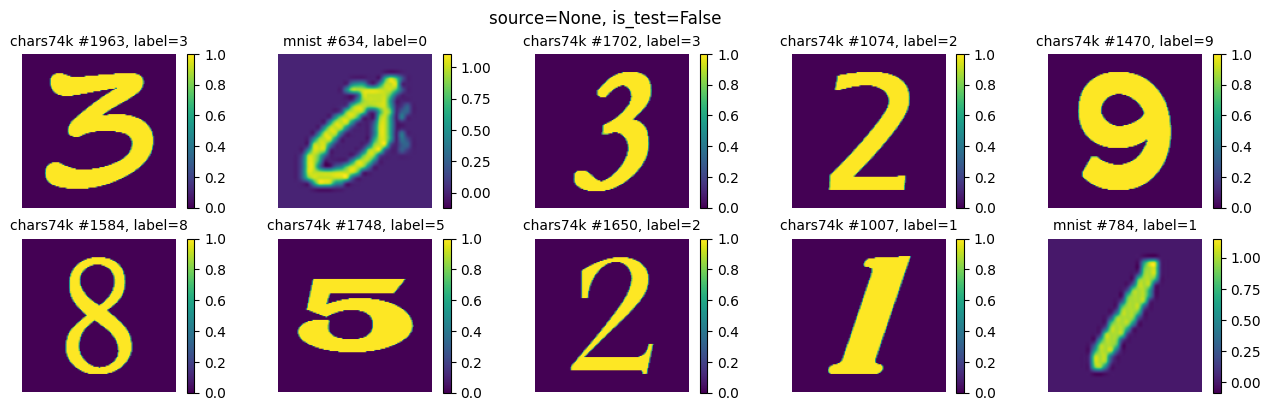

In [93]:
fig = visualize_images(source=None, is_test=False)

## source='mnist', is_test=False

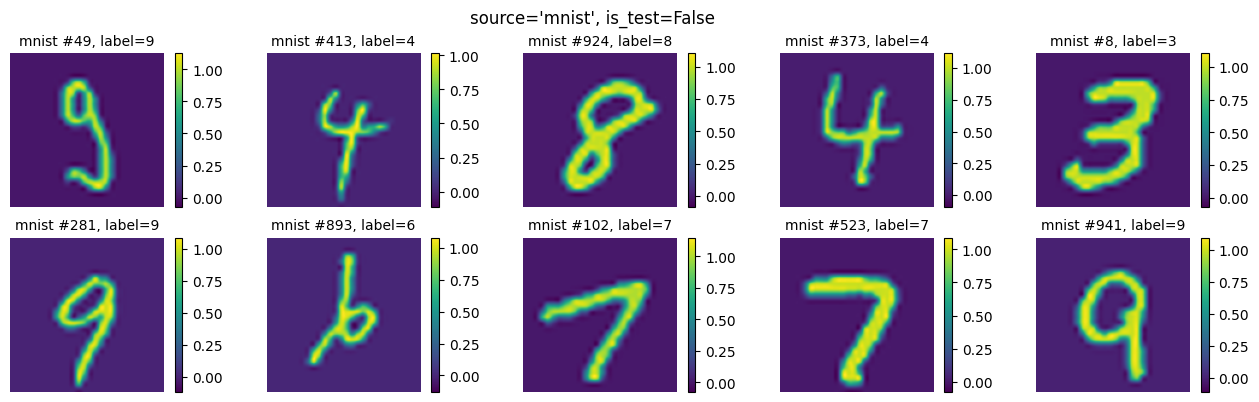

In [94]:
fig = visualize_images(source='mnist', is_test=False)

## source='chars74k', is_test=False

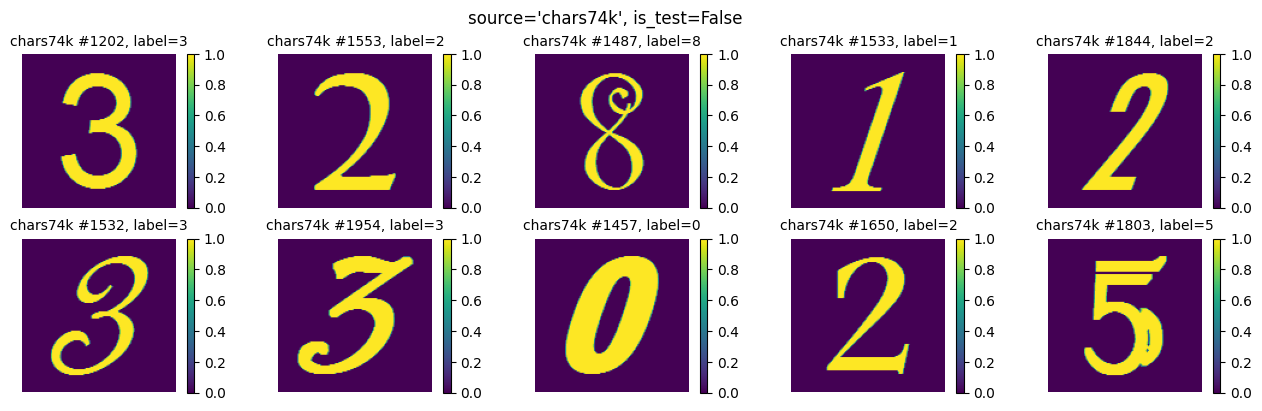

In [98]:
fig = visualize_images(source='chars74k', is_test=False)

## source=None, is_test=True

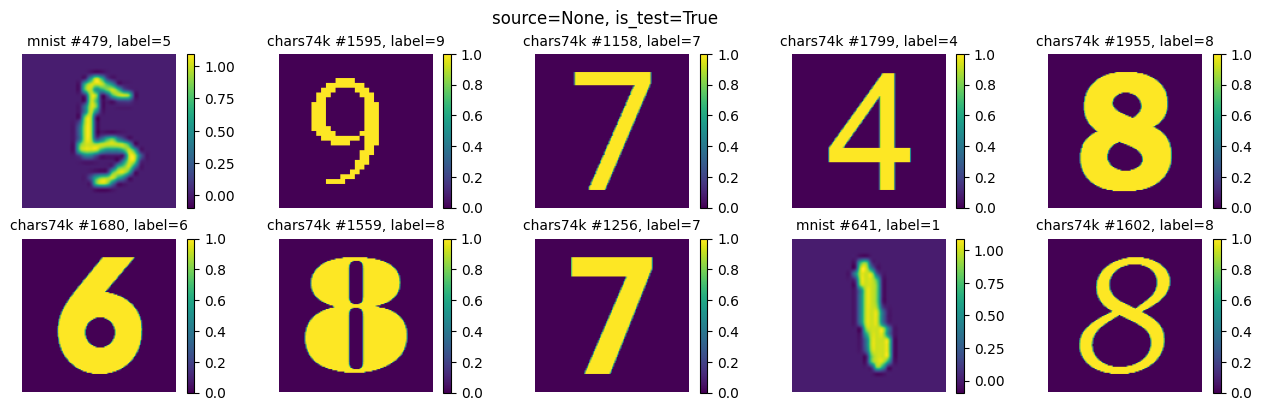

In [95]:
fig = visualize_images(source=None, is_test=True)

## source='mnist', is_test=True

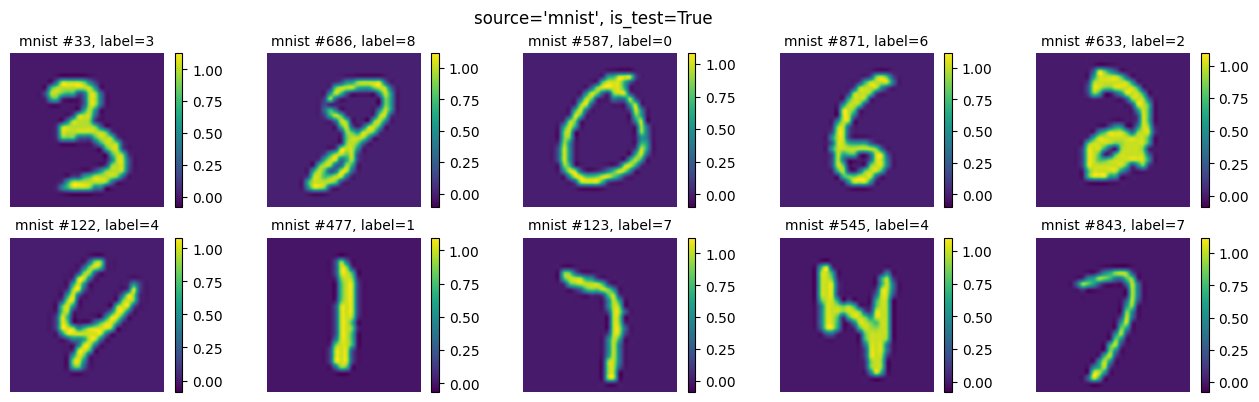

In [105]:
fig = visualize_images(source='mnist', is_test=True)

## source='chars74k', is_test=True

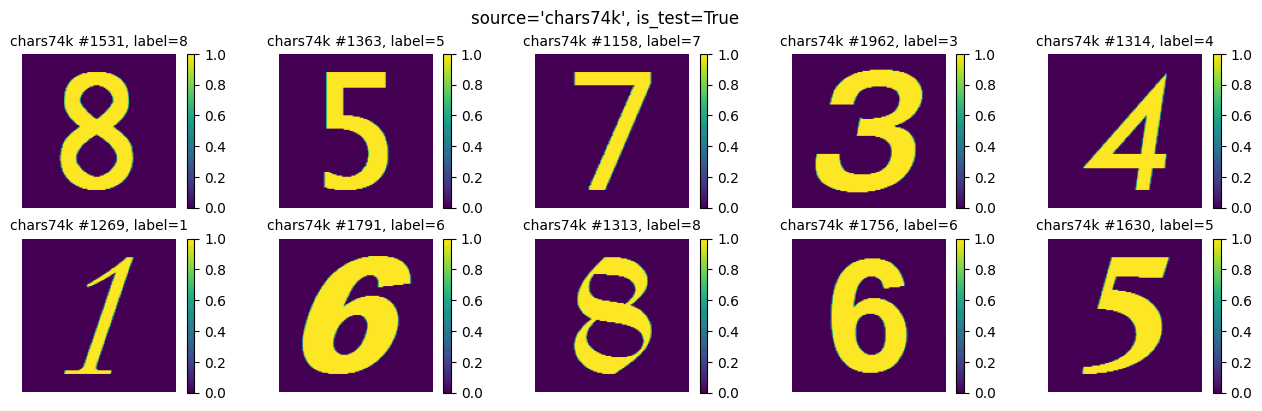

In [103]:
fig = visualize_images(source='chars74k', is_test=True)

# LaunchIt!

In [10]:
# @launchit.disable
launchit_t0 = time.time()

In [11]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{CONFIG.model_group_uri}.{CONFIG.self_name}'))
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars)
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Creating /home/misha/dev/mine/neurovision/16_hybrid/16a_dataset_01-launch1.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/16_hybrid/16a_dataset_01-launch1.ipynb"
